# Monitor State Change Analysis

This notebook analyzes `monitor.csv` as an event sequence instead of a time series. State changes are detected from row-to-row count changes, and every rejected request is expanded into its own event. The source CSV is only read; it is never modified.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

## Load Monitor Data

In [15]:
log_path = '/home/kuscu/DRe-SCale/openfaas-functions/state-tracker/logs/nsgd_last_run/monitor.csv'
df = pd.read_csv(log_path)

if 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'])
elif 'timestamp' in df.columns:
    df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
else:
    raise ValueError("monitor.csv must contain either 'datetime' or 'timestamp'")

if 'timestamp' not in df.columns:
    df['timestamp'] = df['datetime'].astype('int64') / 1_000_000_000

if 'init_total' not in df.columns:
    df['init_total'] = df['init_free'] + df['init_reserved']

if 'rejected_requests_interval' not in df.columns:
    if 'rejected_requests' in df.columns:
        df = df.sort_values(['timestamp', 'datetime']).reset_index(drop=True)
        df['rejected_requests_interval'] = df['rejected_requests'].diff().fillna(df['rejected_requests']).clip(lower=0)
    else:
        df['rejected_requests_interval'] = 0

if 'has_rejection' not in df.columns:
    df['has_rejection'] = df['rejected_requests_interval'] > 0

required_columns = [
    'timestamp', 'datetime', 'cold', 'init_total', 'init_free',
    'init_reserved', 'idle_on', 'busy', 'rejected_requests_interval',
    'has_rejection'
]
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"monitor.csv is missing required columns: {missing_columns}")

df = df.sort_values(['timestamp', 'datetime']).reset_index(drop=True)
df['source_row'] = df.index
df['rejected_requests_interval'] = df['rejected_requests_interval'].fillna(0).astype(int).clip(lower=0)
df['has_rejection'] = df['has_rejection'].astype(bool) | (df['rejected_requests_interval'] > 0)

print(f"Rows: {len(df):,}")
print(f"Time range: {df['datetime'].min()} -> {df['datetime'].max()}")
print(f"Total rejected requests from intervals: {df['rejected_requests_interval'].sum():,}")
display(df.head())

Rows: 215,454
Time range: 2026-05-15 11:00:04 -> 2026-05-15 17:00:39
Total rejected requests from intervals: 943


,timestamp,datetime,cold,idle_on,busy,init_total,init_free,init_reserved,nsgd_cost,has_rejection,...,ready_pods,not_ready_pods,inflight_requests,rejected_requests_interval,rejected_requests,latest_cost,cost_delta,iteration,phase,source_row
0,1.778843e+09,2026-05-15 11:00:04,23,1,0,0,0,0,2,False,...,1,0,0,0,0,NaN,NaN,NaN,NaN,0
1,1.778843e+09,2026-05-15 11:00:04,23,1,0,0,0,0,2,False,...,1,0,0,0,0,NaN,NaN,NaN,NaN,1
2,1.778843e+09,2026-05-15 11:00:04,23,1,0,0,0,0,2,False,...,1,0,0,0,0,NaN,NaN,NaN,NaN,2
3,1.778843e+09,2026-05-15 11:00:05,23,1,0,0,0,0,2,False,...,1,0,0,0,0,NaN,NaN,NaN,NaN,3
4,1.778843e+09,2026-05-15 11:00:05,23,1,0,0,0,0,2,False,...,1,0,0,0,0,NaN,NaN,NaN,NaN,4


## Detect State Changes

Normal count changes create at most one event per monitor row. Rejections are expanded so that each rejected request becomes one separate `rejection` event.

In [16]:
state_columns = ['cold', 'init_total', 'init_free', 'init_reserved', 'idle_on', 'busy']

for col in state_columns:
    df[f'delta_{col}'] = df[col].diff().fillna(0).astype(int)

def classify_state_change(row):
    dcold = row['delta_cold']
    dinit = row['delta_init_total']
    didle = row['delta_idle_on']
    dbusy = row['delta_busy']
    dreserved = row['delta_init_reserved']

    if dcold < 0 and dinit > 0:
        return 'cold_to_init'
    if dinit < 0 and didle > 0:
        return 'init_to_idle'
    if dinit < 0 and dbusy > 0:
        return 'init_to_busy'
    if didle < 0 and dbusy > 0:
        return 'idle_to_busy'
    if dbusy < 0 and didle > 0:
        return 'busy_to_idle'
    if dbusy < 0:
        return 'busy_to_done'
    if dreserved != 0:
        return 'init_reserved_change'
    if any(row[f'delta_{col}'] != 0 for col in state_columns):
        return 'other_change'
    return None

df['state_event_type'] = df.apply(classify_state_change, axis=1)
df['has_state_change'] = df['state_event_type'].notna()

print(f"Rows with normal state changes: {df['has_state_change'].sum():,}")
print(f"Rows with rejection intervals: {(df['rejected_requests_interval'] > 0).sum():,}")
display(df.loc[df['has_state_change'] | (df['rejected_requests_interval'] > 0), [
    'datetime', 'state_event_type', 'cold', 'init_total', 'idle_on', 'busy',
    'rejected_requests_interval', 'has_rejection'
]].head(20))

Rows with normal state changes: 8,294
Rows with rejection intervals: 804


,datetime,state_event_type,cold,init_total,idle_on,busy,rejected_requests_interval,has_rejection
158,2026-05-15 11:00:20,cold_to_init,20,3,0,1,0,False
168,2026-05-15 11:00:21,cold_to_init,16,7,0,1,0,False
170,2026-05-15 11:00:21,init_reserved_change,16,7,0,1,2,True
178,2026-05-15 11:00:22,cold_to_init,13,10,0,1,0,False
179,2026-05-15 11:00:22,init_reserved_change,13,10,0,1,1,True
187,2026-05-15 11:00:23,init_reserved_change,13,10,0,1,0,False
188,2026-05-15 11:00:23,cold_to_init,9,14,0,1,0,False
190,2026-05-15 11:00:23,init_reserved_change,9,14,0,1,1,True
199,2026-05-15 11:00:24,init_to_idle,9,12,2,1,0,False
200,2026-05-15 11:00:24,init_to_idle,9,11,3,1,0,False


## Build Expanded Event Table

In [17]:
event_rows = []
base_columns = [
    'source_row', 'timestamp', 'datetime', 'cold', 'init_total', 'init_free',
    'init_reserved', 'idle_on', 'busy', 'rejected_requests_interval',
    'has_rejection'
]
optional_columns = [
    'nsgd_cost', 'total_pods', 'ready_pods', 'not_ready_pods',
    'inflight_requests', 'rejected_requests', 'latest_cost', 'cost_delta',
    'iteration', 'phase'
]
available_columns = base_columns + [col for col in optional_columns if col in df.columns]

for _, row in df.iterrows():
    base = {col: row[col] for col in available_columns}

    if pd.notna(row['state_event_type']):
        event = base.copy()
        event['event_type'] = row['state_event_type']
        event['event_group'] = 'state_change'
        event['rejection_number_in_row'] = 0
        event['rejection_event_count'] = 0
        for col in state_columns:
            event[f'delta_{col}'] = row[f'delta_{col}']
        event_rows.append(event)

    for rejection_number in range(1, int(row['rejected_requests_interval']) + 1):
        event = base.copy()
        event['event_type'] = 'rejection'
        event['event_group'] = 'rejection'
        event['rejection_number_in_row'] = rejection_number
        event['rejection_event_count'] = 1
        for col in state_columns:
            event[f'delta_{col}'] = 0
        event_rows.append(event)

events = pd.DataFrame(event_rows)
if events.empty:
    raise ValueError('No state-change or rejection events were detected in monitor.csv')

events = events.reset_index(drop=True)
events['event_id'] = np.arange(len(events))
events['cumulative_rejections'] = events['rejection_event_count'].cumsum()

ordered_columns = [
    'event_id', 'event_type', 'event_group', 'source_row', 'timestamp', 'datetime',
    'cold', 'init_total', 'init_free', 'init_reserved', 'idle_on', 'busy',
    'rejection_number_in_row', 'rejected_requests_interval',
    'rejection_event_count', 'cumulative_rejections'
]
ordered_columns += [col for col in optional_columns if col in events.columns and col not in ordered_columns]
ordered_columns += [f'delta_{col}' for col in state_columns]
events = events[ordered_columns]

print(f"Total expanded events: {len(events):,}")
print(f"State-change events: {(events['event_group'] == 'state_change').sum():,}")
print(f"Rejection events: {(events['event_group'] == 'rejection').sum():,}")
display(events.head(20))

Total expanded events: 9,237
State-change events: 8,294
Rejection events: 943


,event_id,event_type,event_group,source_row,timestamp,datetime,cold,init_total,init_free,init_reserved,...,latest_cost,cost_delta,iteration,phase,delta_cold,delta_init_total,delta_init_free,delta_init_reserved,delta_idle_on,delta_busy
0,0,cold_to_init,state_change,158,1.778843e+09,2026-05-15 11:00:20,20,3,3,0,...,NaN,NaN,NaN,NaN,-3,3,3,0,-1,1
1,1,cold_to_init,state_change,168,1.778843e+09,2026-05-15 11:00:21,16,7,5,2,...,NaN,NaN,NaN,NaN,-4,4,2,2,0,0
2,2,init_reserved_change,state_change,170,1.778843e+09,2026-05-15 11:00:21,16,7,7,0,...,NaN,NaN,NaN,NaN,0,0,2,-2,0,0
3,3,rejection,rejection,170,1.778843e+09,2026-05-15 11:00:21,16,7,7,0,...,NaN,NaN,NaN,NaN,0,0,0,0,0,0
4,4,rejection,rejection,170,1.778843e+09,2026-05-15 11:00:21,16,7,7,0,...,NaN,NaN,NaN,NaN,0,0,0,0,0,0
5,5,cold_to_init,state_change,178,1.778843e+09,2026-05-15 11:00:22,13,10,9,1,...,NaN,NaN,NaN,NaN,-3,3,2,1,0,0
6,6,init_reserved_change,state_change,179,1.778843e+09,2026-05-15 11:00:22,13,10,10,0,...,NaN,NaN,NaN,NaN,0,0,1,-1,0,0
7,7,rejection,rejection,179,1.778843e+09,2026-05-15 11:00:22,13,10,10,0,...,NaN,NaN,NaN,NaN,0,0,0,0,0,0
8,8,init_reserved_change,state_change,187,1.778843e+09,2026-05-15 11:00:23,13,10,9,1,...,NaN,NaN,NaN,NaN,0,0,-1,1,0,0
9,9,cold_to_init,state_change,188,1.778843e+09,2026-05-15 11:00:23,9,14,13,1,...,NaN,NaN,NaN,NaN,-4,4,4,0,0,0


## Event Summary

In [18]:
summary = events['event_type'].value_counts().rename_axis('event_type').reset_index(name='count')
summary['percentage'] = 100 * summary['count'] / len(events)

print(f"Total events: {len(events):,}")
print(f"Unique event types: {events['event_type'].nunique()}")
print(f"First event datetime: {events['datetime'].min()}")
print(f"Last event datetime: {events['datetime'].max()}")
print(f"Total expanded rejection events: {events['rejection_event_count'].sum():,}")
print(f"Rejection event share: {100 * events['rejection_event_count'].sum() / len(events):.2f}%")
display(summary)

Total events: 9,237
Unique event types: 9
First event datetime: 2026-05-15 11:00:20
Last event datetime: 2026-05-15 17:00:39
Total expanded rejection events: 943
Rejection event share: 10.21%


,event_type,count,percentage
0,busy_to_idle,4173,45.177006
1,idle_to_busy,3436,37.198225
2,rejection,943,10.208942
3,other_change,290,3.139547
4,init_to_idle,206,2.230161
5,cold_to_init,162,1.753816
6,init_reserved_change,14,0.151564
7,init_to_busy,11,0.119086
8,busy_to_done,2,0.021652


## State Counts By Event Sequence

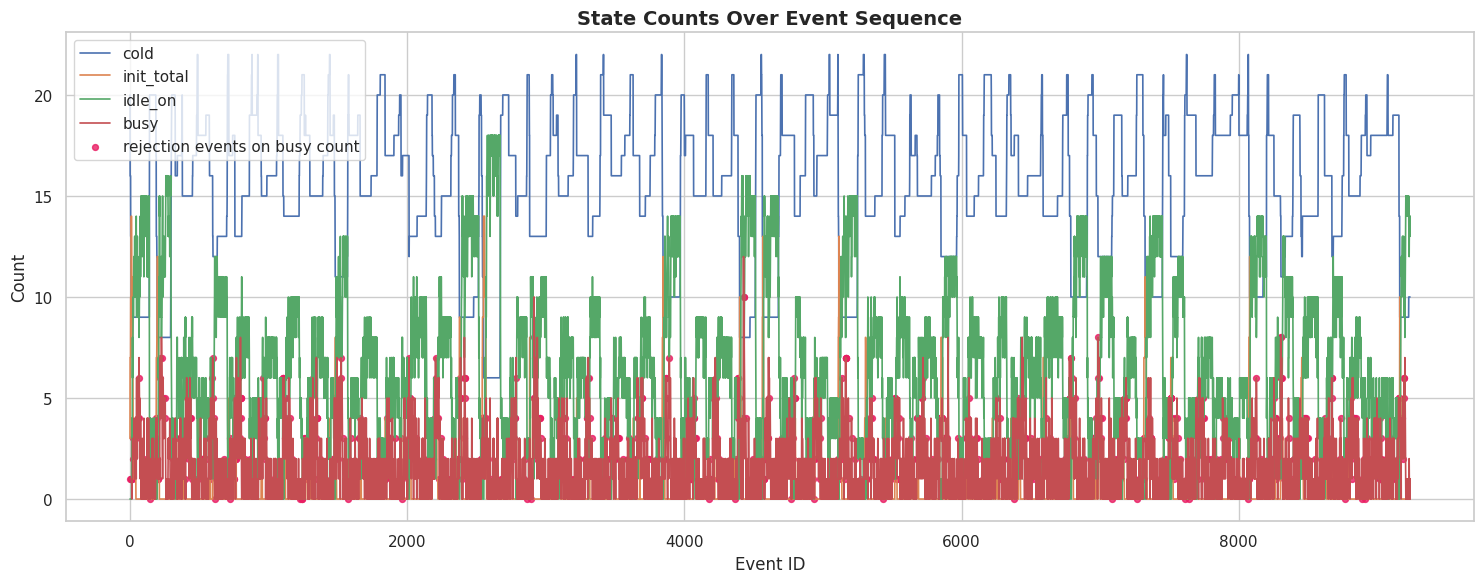

In [19]:
plot_columns = ['cold', 'init_total', 'idle_on', 'busy']

plt.figure(figsize=(15, 6))
for col in plot_columns:
    plt.plot(events['event_id'], events[col], linewidth=1.2, label=col)

rejection_events = events[events['event_type'] == 'rejection']
if not rejection_events.empty:
    plt.scatter(
        rejection_events['event_id'],
        rejection_events['busy'],
        color='#E91E63',
        s=18,
        alpha=0.8,
        label='rejection events on busy count'
    )

plt.title('State Counts Over Event Sequence', fontsize=14, fontweight='bold')
plt.xlabel('Event ID')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

## Event Type Sequence

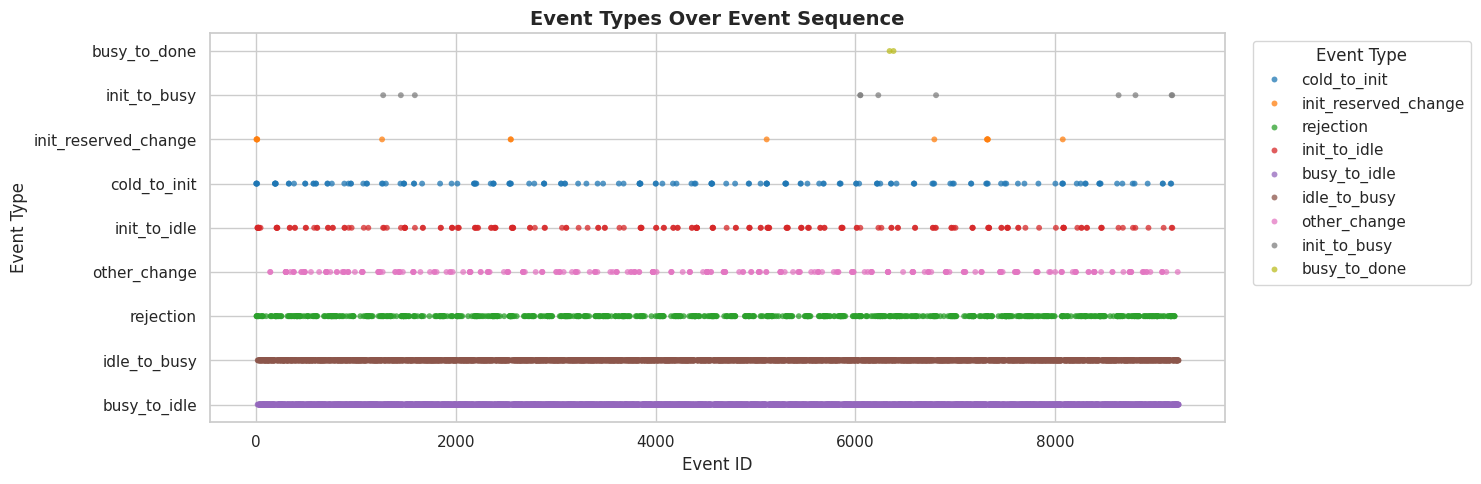

In [20]:
event_order = summary['event_type'].tolist()
event_to_y = {event_type: idx for idx, event_type in enumerate(event_order)}
events['event_type_y'] = events['event_type'].map(event_to_y)

plt.figure(figsize=(15, max(5, 0.45 * len(event_order))))
sns.scatterplot(
    data=events,
    x='event_id',
    y='event_type_y',
    hue='event_type',
    s=18,
    linewidth=0,
    alpha=0.75,
    palette='tab10'
)
plt.yticks(range(len(event_order)), event_order)
plt.title('Event Types Over Event Sequence', fontsize=14, fontweight='bold')
plt.xlabel('Event ID')
plt.ylabel('Event Type')
plt.legend(title='Event Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Event Frequencies

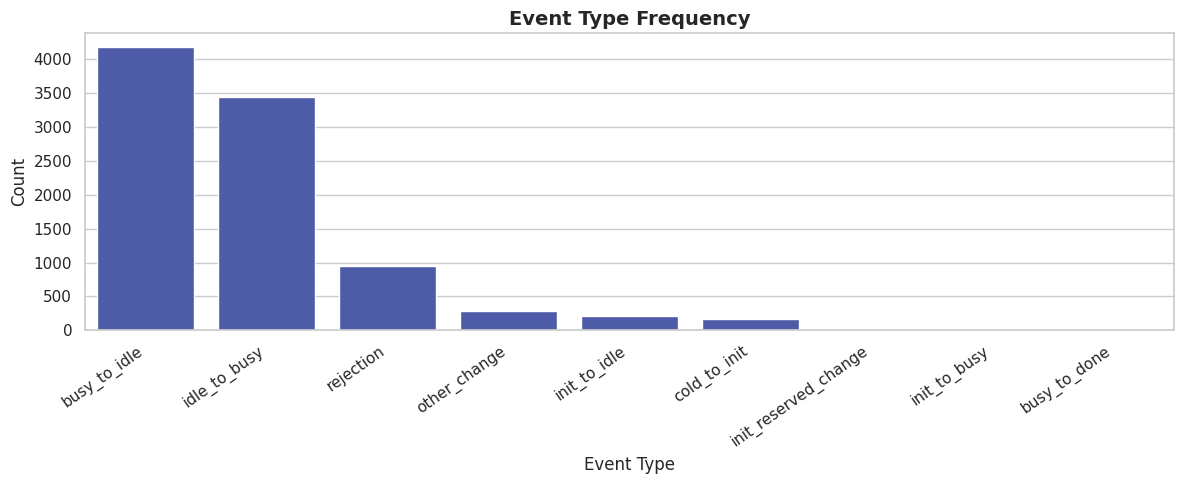

In [21]:
plt.figure(figsize=(12, 5))
sns.barplot(data=summary, x='event_type', y='count', color='#3F51B5')
plt.title('Event Type Frequency', fontsize=14, fontweight='bold')
plt.xlabel('Event Type')
plt.ylabel('Count')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## Rejection Events

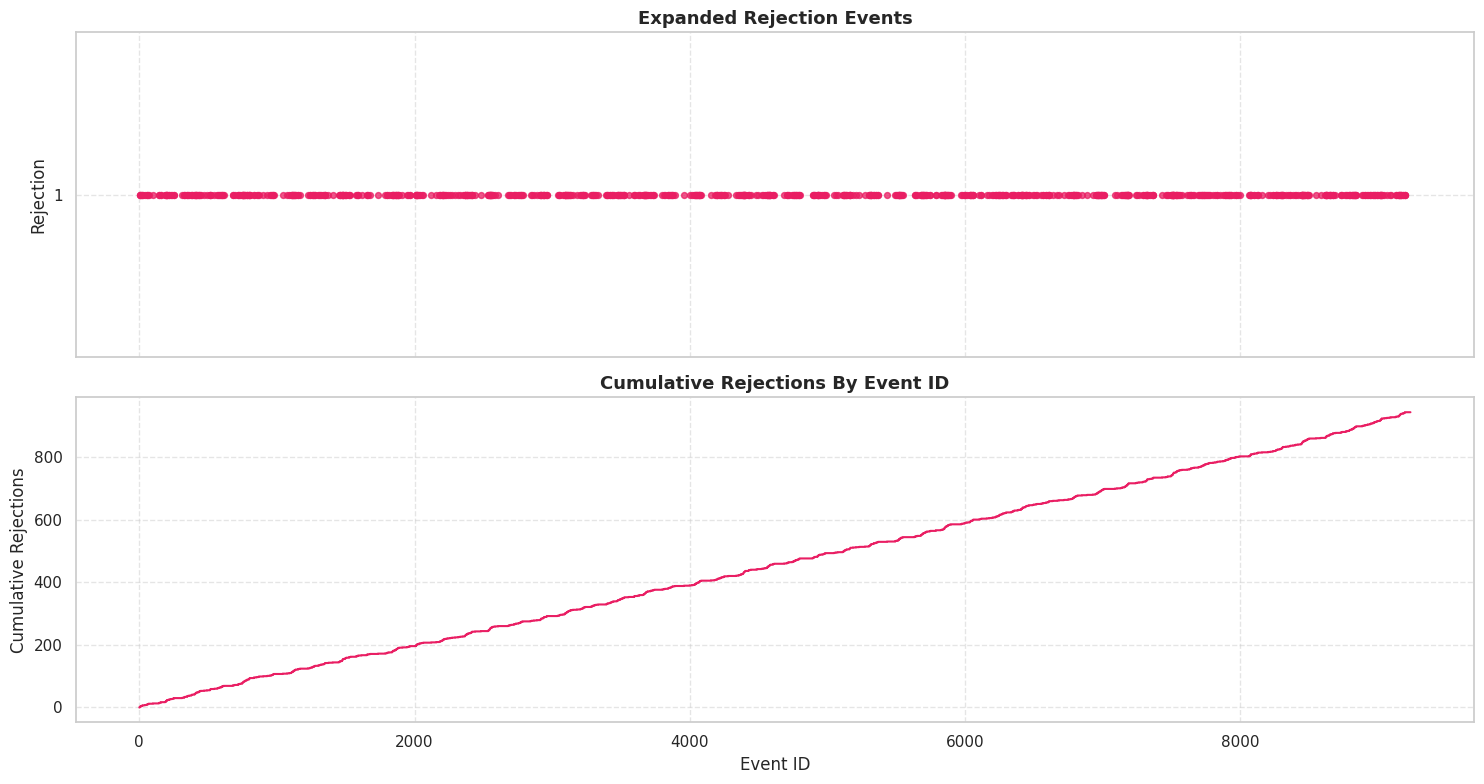

,event_id,event_type,event_group,source_row,timestamp,datetime,cold,init_total,init_free,init_reserved,...,cost_delta,iteration,phase,delta_cold,delta_init_total,delta_init_free,delta_init_reserved,delta_idle_on,delta_busy,event_type_y
3,3,rejection,rejection,170,1.778843e+09,2026-05-15 11:00:21,16,7,7,0,...,NaN,NaN,NaN,0,0,0,0,0,0,2
4,4,rejection,rejection,170,1.778843e+09,2026-05-15 11:00:21,16,7,7,0,...,NaN,NaN,NaN,0,0,0,0,0,0,2
7,7,rejection,rejection,179,1.778843e+09,2026-05-15 11:00:22,13,10,10,0,...,NaN,NaN,NaN,0,0,0,0,0,0,2
11,11,rejection,rejection,190,1.778843e+09,2026-05-15 11:00:23,9,14,14,0,...,NaN,NaN,NaN,0,0,0,0,0,0,2
16,16,rejection,rejection,207,1.778843e+09,2026-05-15 11:00:25,9,11,11,0,...,NaN,NaN,NaN,0,0,0,0,0,0,2
21,21,rejection,rejection,218,1.778843e+09,2026-05-15 11:00:26,9,6,6,0,...,NaN,NaN,NaN,0,0,0,0,0,0,2
25,25,rejection,rejection,227,1.778843e+09,2026-05-15 11:00:27,9,3,3,0,...,NaN,NaN,NaN,0,0,0,0,0,0,2
42,42,rejection,rejection,336,1.778843e+09,2026-05-15 11:00:38,9,1,1,0,...,NaN,NaN,NaN,0,0,0,0,0,0,2
55,55,rejection,rejection,436,1.778843e+09,2026-05-15 11:00:48,9,0,0,0,...,NaN,NaN,NaN,0,0,0,0,0,0,2
56,56,rejection,rejection,436,1.778843e+09,2026-05-15 11:00:48,9,0,0,0,...,NaN,NaN,NaN,0,0,0,0,0,0,2


In [22]:
rejection_events = events[events['event_type'] == 'rejection'].copy()

if rejection_events.empty:
    print('No rejection events found.')
else:
    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

    axes[0].scatter(
        rejection_events['event_id'],
        np.ones(len(rejection_events)),
        color='#E91E63',
        s=18,
        alpha=0.75
    )
    axes[0].set_title('Expanded Rejection Events', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Rejection')
    axes[0].set_yticks([1])
    axes[0].grid(True, linestyle='--', alpha=0.5)

    axes[1].plot(events['event_id'], events['cumulative_rejections'], color='#E91E63', linewidth=1.5)
    axes[1].set_title('Cumulative Rejections By Event ID', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Event ID')
    axes[1].set_ylabel('Cumulative Rejections')
    axes[1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    display(rejection_events.head(20))

## Event Cost Analysis

For event-based analysis, each expanded rejection event receives exactly one rejection penalty. Non-rejection state events keep the state costs from their source row.

In [23]:
W_IDLE_ON = 2
W_BUSY = 1
W_INIT = 5
W_RESERVED = 100
W_REJ = 200

events['cost_idle'] = events['idle_on'] * W_IDLE_ON
events['cost_busy'] = events['busy'] * W_BUSY
events['cost_init'] = events['init_total'] * W_INIT
events['cost_reserved'] = events['init_reserved'] * W_RESERVED
events['cost_rejection'] = np.where(events['event_type'] == 'rejection', W_REJ, 0)
events['total_event_cost'] = (
    events['cost_idle']
    + events['cost_busy']
    + events['cost_init']
    + events['cost_reserved']
    + events['cost_rejection']
)

cost_columns = [
    'cost_idle', 'cost_busy', 'cost_init', 'cost_reserved',
    'cost_rejection', 'total_event_cost'
]

print(f"Average event cost: {events['total_event_cost'].mean():.2f}")
print(f"Average rejection event cost: {events.loc[events['event_type'] == 'rejection', 'total_event_cost'].mean():.2f}")
display(events[['event_id', 'event_type'] + cost_columns].head(20))

Average event cost: 38.49
Average rejection event cost: 221.18


,event_id,event_type,cost_idle,cost_busy,cost_init,cost_reserved,cost_rejection,total_event_cost
0,0,cold_to_init,0,1,15,0,0,16
1,1,cold_to_init,0,1,35,200,0,236
2,2,init_reserved_change,0,1,35,0,0,36
3,3,rejection,0,1,35,0,200,236
4,4,rejection,0,1,35,0,200,236
5,5,cold_to_init,0,1,50,100,0,151
6,6,init_reserved_change,0,1,50,0,0,51
7,7,rejection,0,1,50,0,200,251
8,8,init_reserved_change,0,1,50,100,0,151
9,9,cold_to_init,0,1,70,100,0,171


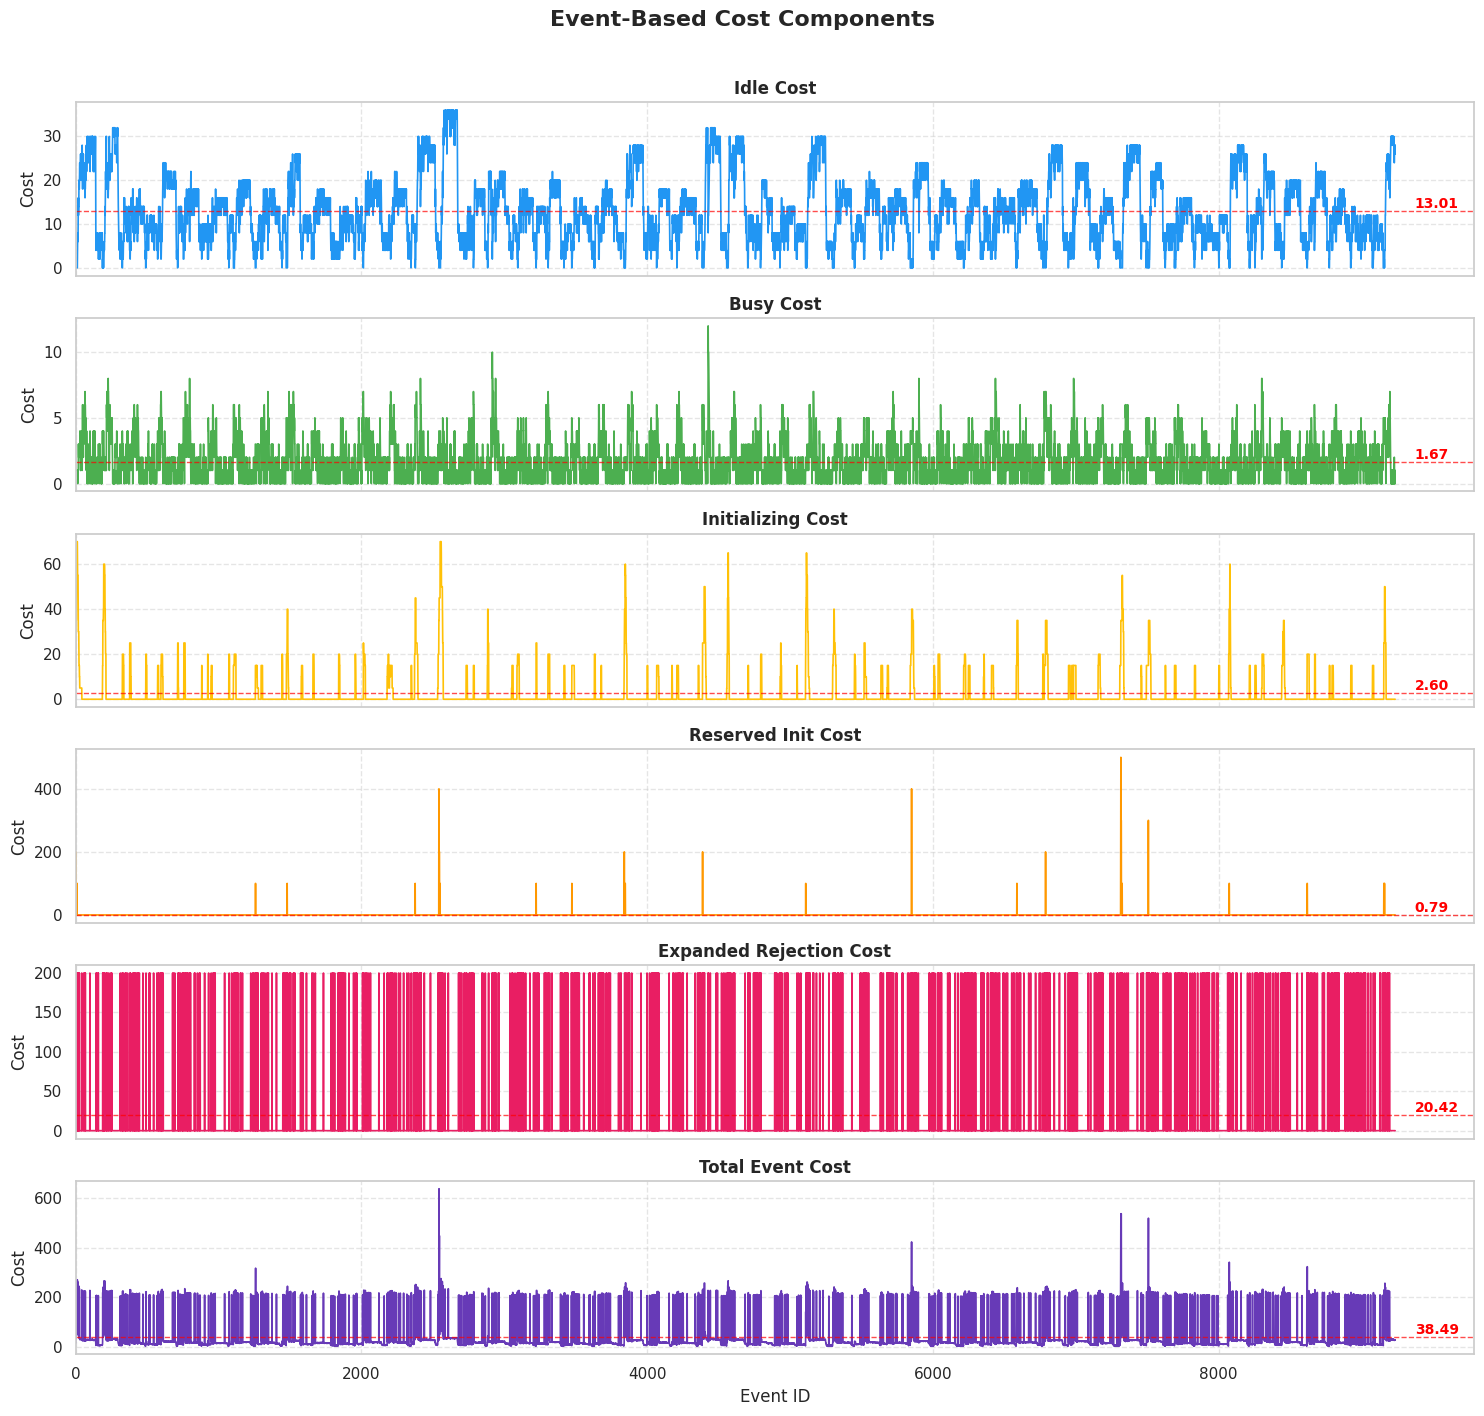

In [24]:
fig, axes = plt.subplots(6, 1, figsize=(15, 14), sharex=True)
x_min = events['event_id'].min()
x_max = events['event_id'].max()
x_padding = max(1, int((x_max - x_min) * 0.015))
plot_specs = [
    ('cost_idle', 'Idle Cost', '#2196F3'),
    ('cost_busy', 'Busy Cost', '#4CAF50'),
    ('cost_init', 'Initializing Cost', '#FFC107'),
    ('cost_reserved', 'Reserved Init Cost', '#FF9800'),
    ('cost_rejection', 'Expanded Rejection Cost', '#E91E63'),
    ('total_event_cost', 'Total Event Cost', '#673AB7'),
]

for ax, (col, title, color) in zip(axes, plot_specs):
    ax.plot(events['event_id'], events[col], color=color, linewidth=1.2)
    avg_val = events[col].mean()
    ax.axhline(avg_val, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.text(
        x_max + x_padding,
        avg_val,
        f'{avg_val:.2f}',
        color='red',
        ha='left',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )
    ax.set_xlim(x_min, x_max + x_padding * 4)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Cost')
    ax.grid(True, linestyle='--', alpha=0.5)

axes[-1].set_xlabel('Event ID')
fig.suptitle('Event-Based Cost Components', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Row-Level Cost Check

This validates the CSV's row-level NSGD cost using `rejected_requests_interval * W_REJ`. This is separate from the expanded event-level cost above.

In [25]:
df['row_cost_idle'] = df['idle_on'] * W_IDLE_ON
df['row_cost_busy'] = df['busy'] * W_BUSY
df['row_cost_init'] = df['init_total'] * W_INIT
df['row_cost_reserved'] = df['init_reserved'] * W_RESERVED
df['row_cost_rejection'] = df['rejected_requests_interval'] * W_REJ
df['row_total_cost'] = (
    df['row_cost_idle']
    + df['row_cost_busy']
    + df['row_cost_init']
    + df['row_cost_reserved']
    + df['row_cost_rejection']
)

if 'nsgd_cost' in df.columns:
    df['row_cost_diff'] = df['row_total_cost'] - df['nsgd_cost']
    display(df['row_cost_diff'].describe())
    display(df.loc[df['row_cost_diff'] != 0, [
        'datetime', 'row_total_cost', 'nsgd_cost', 'row_cost_diff',
        'rejected_requests_interval', 'has_rejection'
    ]].head(20))
else:
    print('nsgd_cost column is not present; skipped row-level cost comparison.')

count    215454.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: row_cost_diff, dtype: float64

,datetime,row_total_cost,nsgd_cost,row_cost_diff,rejected_requests_interval,has_rejection
